In [2]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')


train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123279, 1480)
Training date range: 2018-10-17 to 2023-04-09
Validation data shape: (26357, 1475)
Validation date range: 2023-10-25 to 2024-04-14
Test data shape: (26264, 1475)
Test date range: 2024-10-23 to 2025-04-13


Unnamed: 0  Unnamed: 0.2      PLAYER_NAME  PLAYER_ID    MATCHUP  \
0               0          47.0         Alex Len     203458  ATL @ NYK   
1               1          49.0   Alex Poythress    1627816  ATL @ NYK   
2               2          48.0  DeAndre' Bembry    1627761  ATL @ NYK   
3               3          90.0     Jaylen Adams    1629121  ATL @ NYK   
4               4          87.0       Jeremy Lin     202391  ATL @ NYK   
...           ...           ...              ...        ...        ...   
25872       25872           NaN     Kobi Simmons    1628424  CHA @ CLE   
25873       25873           NaN    Mark Williams    1631109  CHA @ CLE   
25874       25874           NaN    Nick Richards    1630208  CHA @ CLE   
25875       25875           NaN   Svi Mykhailiuk    1629004  CHA @ CLE   
25876       25876           NaN     Theo Maledon    1630177  CHA @ CLE   

      TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0                   ATL  1610612737              NYK          0  21800007   
1                   ATL  1610612737              NYK          0  21800007   
2                   ATL  1610612737              NYK          0  21800007   
3                   ATL  1610612737              NYK          0  21800007   
4                   ATL  1610612737              NYK          0  21800007   
...                 ...         ...              ...        ...       ...   
25872               CHA  1610612766              CLE          0  22201218   
25873               CHA  1610612766              CLE          0  22201218   
25874               CHA  1610612766              CLE          0  22201218   
25875               CHA  1610612766              CLE          0  22201218   
25876               CHA  1610612766              CLE          0  22201218   

        GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  \
0      2018-10-17  L    7    2    4    3    6   0.500     0     2    0.000   
1      2018-10-17  L    9    0    2    4    8   0.500     1     3    0.333   
2      2018-10-17  L    2    4    4    1    4   0.250     0     0      NaN   
3      2018-10-17  L    0    1    1    0    1   0.000     0     1    0.000   
4      2018-10-17  L    8    1    5    3    6   0.500     0     2    0.000   
...           ... ..  ...  ...  ...  ...  ...     ...   ...   ...      ...   
25872  2023-04-09  W    0    3    2    0    1   0.000     0     1    0.000   
25873  2023-04-09  W   22    0   10    9   10   0.900     0     0      NaN   
25874  2023-04-09  W   11    1    8    3    4   0.750     0     0      NaN   
25875  2023-04-09  W   16    6    7    6   18   0.333     2    10    0.200   
25876  2023-04-09  W   18    6    8    7   13   0.538     0     2    0.000   

       FTM  FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0        1    2   0.500     2     2    0    1    3         -14         14.8   
1        0    1   0.000     1     1    1    0    3         -21         11.4   
2        0    0     NaN     0     4    2    0    2         -12         16.8   
3        0    0     NaN     0     1    0    0    0           4          2.7   
4        2    2   1.000     0     5    1    0    2          -5         16.5   
...    ...  ...     ...   ...   ...  ...  ...  ...         ...          ...   
25872    0    0     NaN     1     1    0    0    0           0          6.9   
25873    4    6   0.667     1     9    1    2    2           3         41.0   
25874    5    5   1.000     2     6    1    3    3           8         31.1   
25875    2    2   1.000     4     3    2    0    3           5         36.4   
25876    4    4   1.000     1     7    1    0    3          17         36.6   

       POINT_PER_SHOT       EFG START_POSITION  COMMENT  OFF_RATING  \
0               1.017  0.500000              C      NaN        92.3   
1               1.066  0.562500            NaN      NaN        68.0   
2               0.500  0.250000            NaN      NaN        80.7   
3               0.000  

In [4]:
newFeatures = val_df.columns[val_df.columns.tolist().index('STARTING'):].tolist()
df_subset = val_df[newFeatures]

# top_features = [
#     # Game context
#     'GUARD', 'FORWARD', 'CENTER', 'STARTING',
#     'PLAYER_IS_TEAM_STAR', 'TEAM_STAR_OUT', 'NUM_USUAL_STARTERS_PRESENT', 
#     'HOME_GAME', 'IS_BACK_TO_BACK', 'PLAYER_DAYS_REST', 

#     # Scoring and points
#     'PTS_ROLLING_AVG_40', 'PTS_ROLLING_AVG_15', 'PTS_AVG_TO_DATE',
#     'PTS_WITHOUT_STAR', 'PTS_PER_MIN_ROLLING_AVG_40', 'PTS_PER_MIN',
#     'PTS_PER_36_WITHOUT_STAR', 'PTS_PER_36', 'PTS_PAINT_ROLLING_AVG_15',
#     'PTS_PAINT_AVG_TO_DATE',

#     # Usage and efficiency
#     'EXPECTED_USAGE_MIN', 'E_USG_PCT_ROLLING_AVG_40', 'E_USG_PCT_AVG_TO_DATE',
#     'E_USG_PCT_ROLLING_AVG_5', 'E_USG_PCT_ROLLING_AVG_15', 'E_USG_PCT_ROLLING_AVG_10',
#     'E_USG_PCT_LAG_1', 'USG_PCT_WITHOUT_STAR', 'USG_PCT_ROLLING_AVG_40',
#     'USG_X_TEAM_OFF',

#     # Field goal attempts and accuracy
#     'FGA_ROLLING_AVG_10', 'FGA_ROLLING_AVG_15', 'FGA_LAG_1',
#     'FGA_WITHOUT_STAR', 'FGA_EXTREME_VOLATILITY', 'UFGA_ROLLING_AVG_15',
#     'UFGA_AVG_TO_DATE', 'CFGA_ROLLING_AVG_10', 'CFGM_STD_LAST_40',
#     'CFGM_LAG_1', 'DFGA_ROLLING_AVG_10', 'DFGA_STD_LAST_40', 'DFGM_STD_LAST_40',

#     # Three-point attempts and efficiency
#     'FG3A_ROLLING_AVG_10', 'FG3A_ROLLING_AVG_5', 'FG3A_WITHOUT_STAR',

#     # Team and opponent context
#     'TEAM_PTS_ROLLING_AVG_5', 'TEAM_OFF_RATING_ROLLING_AVG_5',
#     'TEAM_DEF_RATING_ROLLING_AVG_5', 'TEAM_AST_ROLLING_AVG_5',
#     'TEAM_STAR_OUT_X_USG', 'TEAM_STAR_OUT_X_PTS',
#     'TEAM_STAR_OUT_X_MIN',

#     # Player vs opponent matchups
#     'PLAYER_PAINT_X_OPP_PAINT_DEF', 'PLAYER_PAINT_X_OPP_PAINT_DEF_RECENT','PLAYER_MID_X_OPP_MID_DEF', 
#     'PLAYER_3PT_X_OPP_3PT_DEF_FORWARD', 'PLAYER_3PT_X_OPP_3PT_DEF_CENTER', 'PLAYER_3PT_X_OPP_3PT_DEF_GUARD_RECENT', 
#     'OPP_PTS_PAINT_STD_LAST_40', 'OPP_TEAM_PACE_ROLLING_AVG_10', 'PLAYER_3PT_X_OPP_3PT_DEF_GUARD', 
#     'PLAYER_3PT_X_OPP_3PT_DEF_FORWARD_RECENT','PLAYER_3PT_X_OPP_3PT_DEF_CENTER_RECENT',

#     # Paint and zone scoring distribution
#     'percentagePointsPaint_AVG_TO_DATE', 'percentagePointsPaint_EXPANDING_VOLATILITY_TO_DATE',
#     'percentagePointsPaint_ROLLING_AVG_40', 'percentagePointsPaint_ROLLING_AVG_15',
#     'percentagePointsPaint_ROLLING_AVG_10', 'percentagePointsPaint_ROLLING_AVG_5',
#     'percentagePointsMidrange2pt_STD_LAST_40', 'percentagePoints2pt_ROLLING_AVG_40',
#     'percentagePoints2pt_AVG_TO_DATE', 'percentagePoints3pt_ROLLING_AVG_5',
#     'percentageFieldGoalsAttempted2pt_STD_LAST_40',

#     # Assisted and unassisted patterns
#     'percentageAssisted2pt_ROLLING_AVG_15', 'percentageAssisted3pt_LAG_1',
#     'percentageUnassistedFGM_AVG_TO_DATE',

#     # Free throws
#     'FTM_ROLLING_AVG_15', 'FTM_STD_LAST_40', 'percentagePointsFreeThrow_ROLLING_AVG_40',

#     # Pace, possessions, and tempo
#     'POSS_ROLLING_AVG_15', 'SPD_AVG_TO_DATE',

#     # Fantasy and impact metrics
#     'FANTASY_PTS_ROLLING_AVG_40', 'FANTASY_PTS_STD_LAST_40',
#     'PIE_WITHOUT_STAR', 'PIE_LAG_2', 'NET_RATING_ROLLING_AVG_15', 
#     'TS_PCT_ROLLING_AVG_40', 'EFG_X_MIN', 'PF_AVG_TO_DATE',

#     # Player-specific splits (home/away averages)
#     'PLAYER_HOME_AVG_percentagePointsPaint_TO_DATE',
#     'PLAYER_HOME_AVG_E_USG_PCT_TO_DATE', 'PLAYER_HOME_AVG_BLK_TO_DATE',
#     'PLAYER_HOME_AVG_OPP_PTS_PAINT_TO_DATE', 'PLAYER_HOME_AVG_FANTASY_PTS_TO_DATE',
#     'PLAYER_HOME_AVG_PFD_TO_DATE', 'PLAYER_HOME_AVG_percentagePointsFreeThrow_TO_DATE',
#     'PLAYER_AWAY_AVG_percentagePointsPaint_TO_DATE',
#     'PLAYER_AWAY_AVG_percentagePointsMidrange2pt_TO_DATE',
#     'PLAYER_AWAY_AVG_percentagePoints2pt_TO_DATE',
#     'PLAYER_AWAY_AVG_PTS_TO_DATE', 'PLAYER_AWAY_AVG_DFGA_TO_DATE',

#     # Matchup aggregates
#     'MATCHUP_AVG_PTS_LAST_3_TO_DATE', 'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
#     'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE', 'MATCHUP_AVG_USG_PCT_LAST_5_TO_DATE'
# ]

Drop 2018 from training. Add 2023-24.

• New training: 2019-2024.

• Validation: early 2025 (first half).

• Test: late 2025 or full 2025-26 once it ends.

In [18]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['PTS'], 
    top_n=61
)
top_features = [f for f in top_features if f != 'PTS_X_TEAM_TOTAL']
# Apply the same feature selection to your other datasets
test_df_selected = test_df[top_features]
val_df_selected = val_df[top_features]

# Get the selected training data
train_df_selected = train_df[top_features]

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 60 features from your newFeatures array
Top 10 most important features:
1. PTS_ROLLING_AVG_40
2. PTS_ROLLING_AVG_15
3. EXPECTED_USAGE_MIN
4. FGA_ROLLING_AVG_10
5. FGA_ROLLING_AVG_15
6. FG3A_ROLLING_AVG_10
7. FGA_LAG_1
8. PTS_WITHOUT_STAR
9. FG3A_ROLLING_AVG_5
10. PLAYER_PAINT_X_OPP_PAINT_DEF


# XGBOOST MODEL

In [19]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 5.31084631193901, 'MAE': 4.0038749827357885, 'R2': 0.6506143808364868, 'best_iteration': 568}
Test metrics: {'RMSE': 5.368002698553728, 'MAE': 4.04897793161179, 'R2': 0.6276489496231079}


In [21]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(30).reset_index(drop=True)
bottom25 = feature_importance.tail(30).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                                 TOP_FEATURES  TOP_IMPORTANCE                                    BOTTOM_FEATURES  BOTTOM_IMPORTANCE
                           PTS_ROLLING_AVG_15        0.238270                       PTS_PER_MIN_X_OPP_DEF_RATING           0.003860
                           PTS_ROLLING_AVG_40        0.162631                           E_USG_PCT_ROLLING_AVG_10           0.003803
                           EXPECTED_USAGE_MIN        0.129288                      TEAM_OFF_RATING_ROLLING_AVG_5           0.003378
                              PTS_AVG_TO_DATE        0.116530                                     USG_X_TEAM_OFF           0.003369
                                     STARTING        0.038861                               USG_X_OPP_DEF_RATING           0.003336
                 PLAYER_PAINT_X_OPP_PAINT_DEF        0.032987                                FG3A_ROLLING_AVG_40           0.003322
                           FGA_R

In [22]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,HOME_GAME,MIN
0,5,29.125910,24.125910,Tyrese Maxey,PHI vs. GSW,126,119.0,1,0,1,1,39.82
1,3,23.706543,20.706543,Desmond Bane,MEM @ OKC,104,125.0,1,0,1,0,31.80
2,5,25.676741,20.676741,Brandon Ingram,NOP vs. OKC,109,119.0,1,0,1,1,18.90
3,0,20.509905,20.509905,Anfernee Simons,POR vs. LAC,89,118.0,1,0,1,1,29.87
4,5,24.416029,19.416029,Tyrese Maxey,PHI vs. POR,102,119.0,1,0,1,1,23.18
5,3,21.809313,18.809313,Stephen Curry,GSW vs. HOU,96,106.0,1,0,1,1,32.67
6,8,26.345858,18.345858,Ja Morant,MEM vs. SAC,115,110.0,1,0,1,1,27.82
7,11,29.315102,18.315102,Cade Cunningham,DET vs. OKC,107,113.0,1,1,0,1,29.02
8,4,22.249163,18.249163,Damian Lillard,MIL @ MEM,99,122.0,1,0,0,0,33.35
9,6,24.194054,18.194054,Jordan Poole,WAS @ CHA,124,114.0,1,0,1,0,31.63


In [23]:
joblib.dump(xgbModel, 'Models/xgbModel.pkl')
joblib.dump(top_features, 'Models/top_features.pkl')

['Models/top_features.pkl']

C:\Users\alexg\AppData\Local\Temp\ipykernel_22740\1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_22740\1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


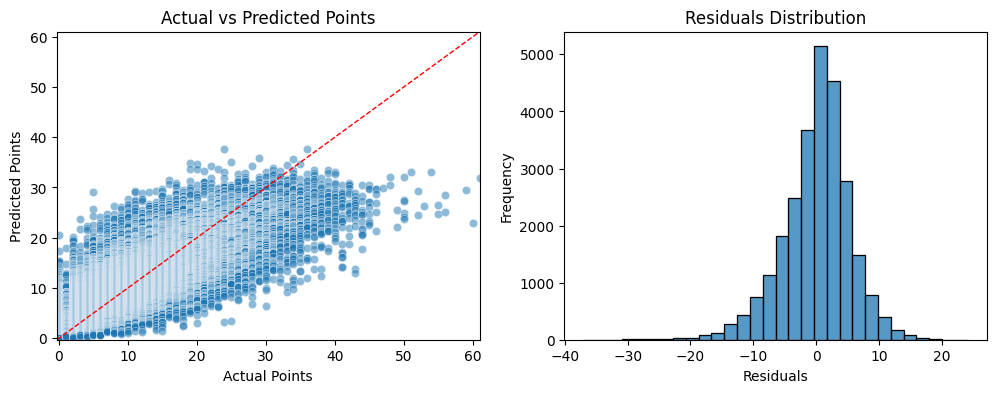

In [24]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

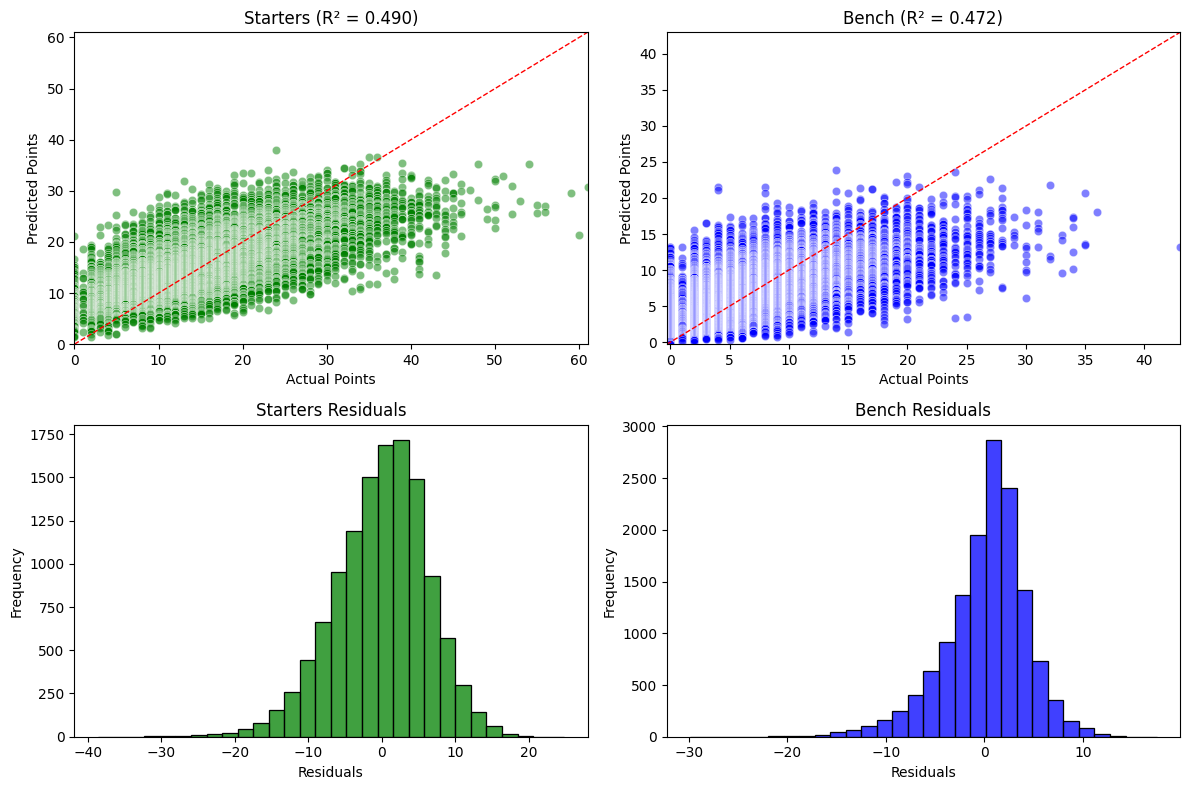

In [11]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


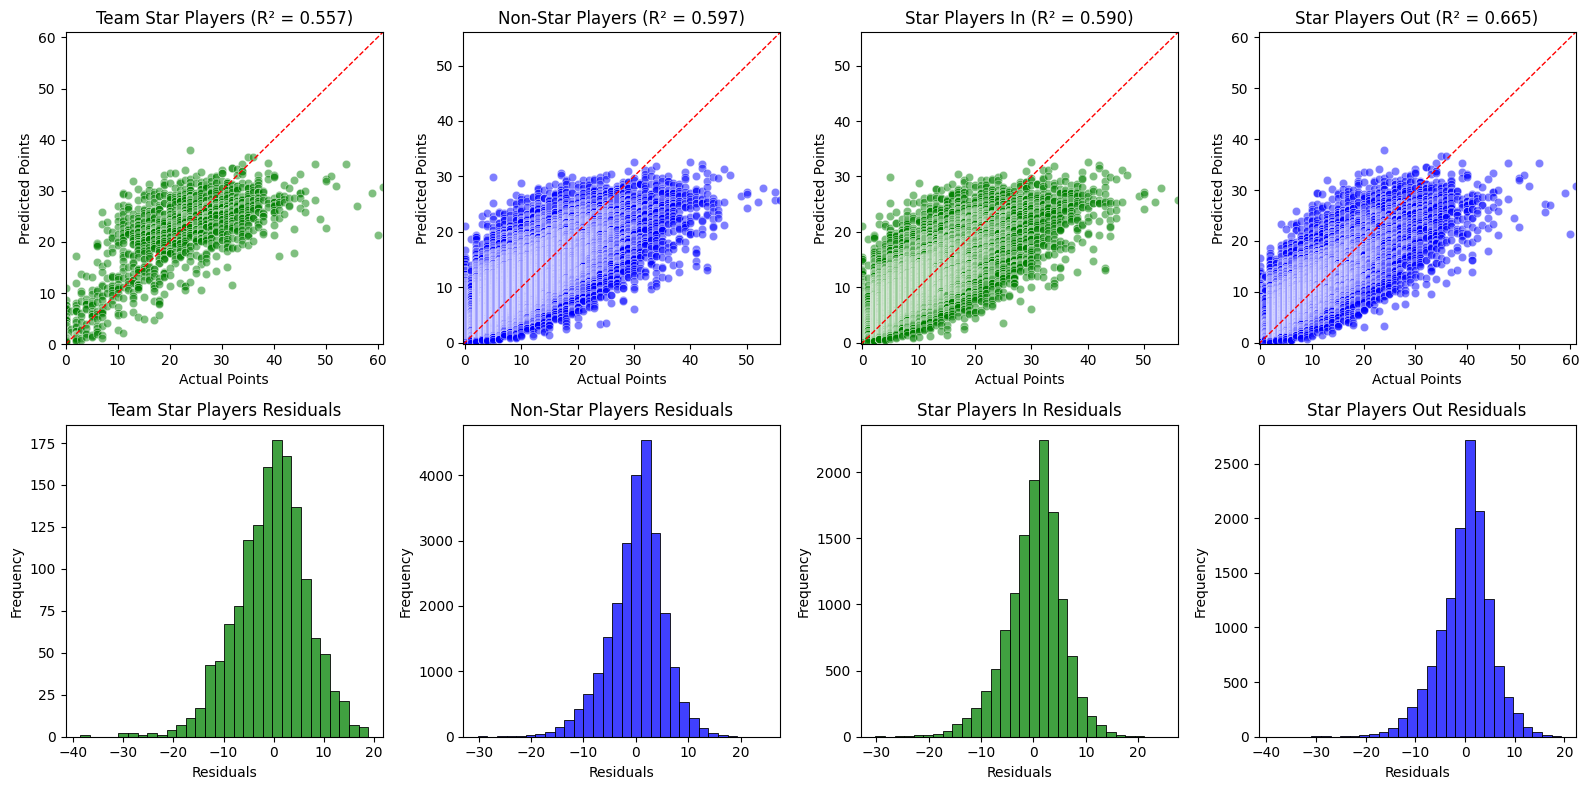

In [12]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

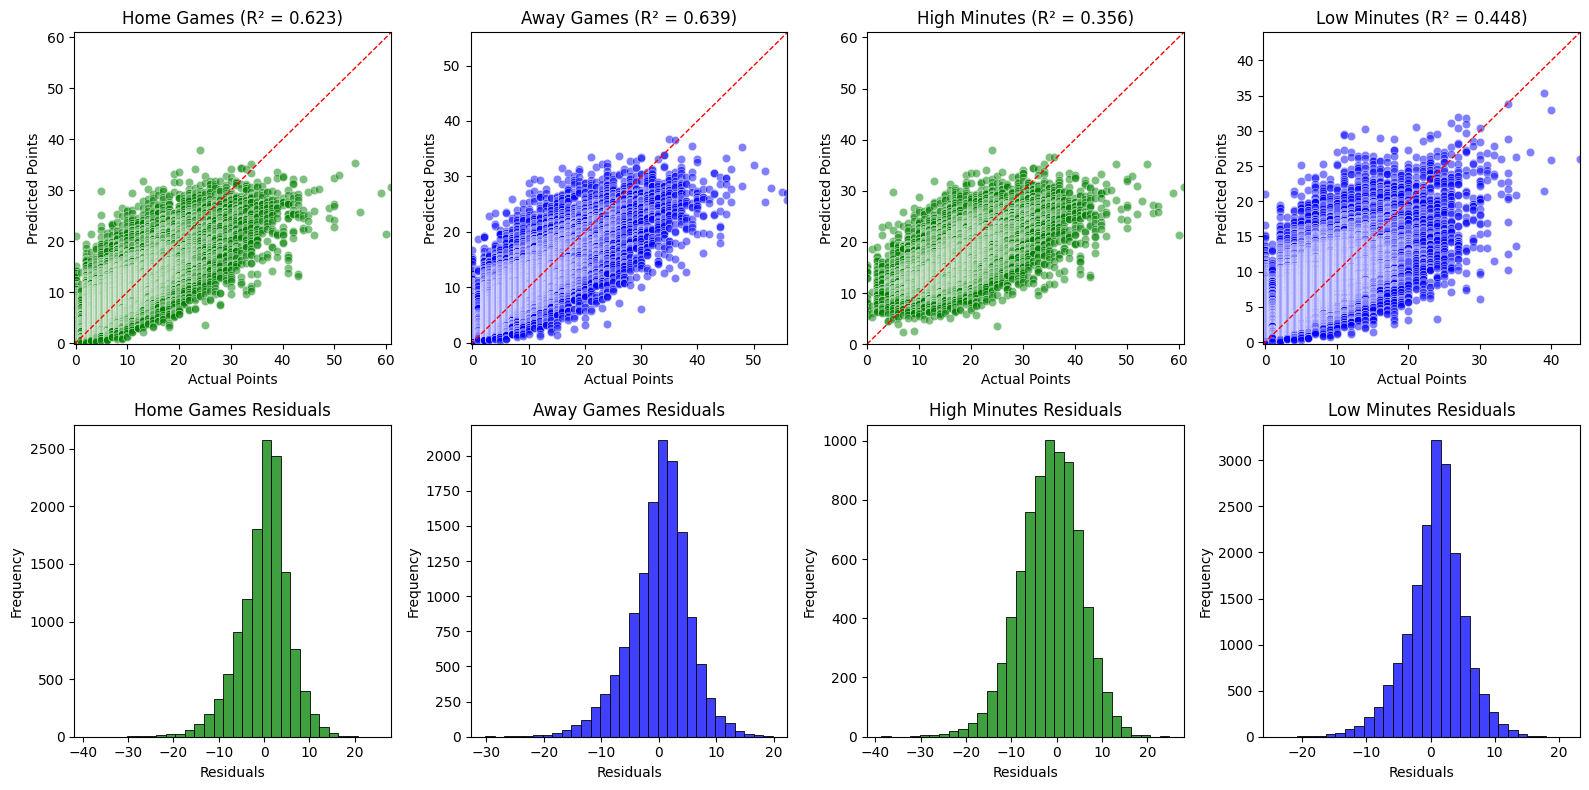

In [13]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()